# Day 08. Exercise 04
# Regression

## 0. Imports

In [2]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import train_test_split, KFold, cross_val_score, cross_val_predict, cross_validate, GridSearchCV, RandomizedSearchCV
from sklearn import linear_model, metrics
from matplotlib import pyplot as plt
from collections import Counter

## 1. Preprocessing

1. Read the file [`checker_regression.csv`](https://drive.google.com/file/d/1L8auBzJEghWFewznhhFpcrqxW4GqcfRY/view?usp=sharing).
2. Fill the missing values in it with `0`.
3. Make a split of your dataset on train and test with parameters `test_size=0.2`.

In [4]:
df = pd.read_csv('../data/checker_regression.csv')
df

,uid,num_commits,pageviews,AVG(diff)
0,user_1,62,28.0,NaN
1,user_1,62,28.0,NaN
2,user_1,62,28.0,NaN
3,user_1,62,28.0,NaN
4,user_1,62,28.0,NaN
...,...,...,...,...
72,user_31,128,NaN,-104.75
73,user_4,40,NaN,-175.60
74,user_6,15,NaN,-62.60
75,user_7,8,NaN,-115.50


In [5]:
df.drop_duplicates(inplace=True)
df.drop(columns='uid', inplace=True)

In [6]:
df.fillna(0, inplace=True)

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 29 entries, 0 to 76
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   num_commits  29 non-null     int64  
 1   pageviews    29 non-null     float64
 2   AVG(diff)    29 non-null     float64
dtypes: float64(2), int64(1)
memory usage: 928.0 bytes


In [8]:
X = df.drop(columns='AVG(diff)')
y = df['AVG(diff)']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=21)

## 2. Crossvalidation

1. Write a function `crossval` that takes as arguments: `n_splits` for `KFold()`, `X`, `y`, model instantiated class with the parameters of the model (keep in mind: `random_state=21`) and returns for a given model class a result like this:

```
train -  2696.4496895424836   |   test -  1589.9979527104958
train -  2660.957874001452   |   test -  2075.102636027137
train -  2847.315529246795   |   test -  320.911928168403
train -  2500.7691099659237   |   test -  4132.461382030178
train -  2643.927917295123   |   test -  2237.8140952197878
train -  2396.295678819444   |   test -  4509.650064742476
train -  2003.402267924976   |   test -  8403.491474908551
train -  2531.876094212613   |   test -  3135.944102735099
train -  2683.1795186023123   |   test -  1796.01426292594
train -  2537.1192483996338   |   test -  3439.29824116941
Average RMSE on crossval is 3164.0686140637476
```

2. Run the function for `LinearRegression`, `DecisionTreeRegressor`, `RandomForestRegressor`. You may choose the parameters by yourself, but find the good enough for you.

In [9]:
def crossval(n_splits, X, y, model):
    kf = KFold(n_splits=n_splits, random_state=21, shuffle=True)
    scores = cross_validate(estimator=model, X=X, y=y, cv=kf, return_train_score=True, scoring='neg_root_mean_squared_error')
    for train_score, test_score in zip(scores['train_score'], scores['test_score']):
        print(f'train -  {-train_score:}   |   test -  {-test_score}')
    test_scores = np.array(scores['test_score'])
    print(f'Average RMSE on crossval is {-test_scores.mean()}')

In [10]:
lreg = linear_model.LinearRegression()
crossval(10, X_train, y_train, lreg)

train -  53.33351096491692   |   test -  115.2394318363867
train -  62.409919772255556   |   test -  69.35808794733022
train -  64.75146423244131   |   test -  52.395419621714424
train -  64.04094981627755   |   test -  78.18810821407222
train -  63.574089717062186   |   test -  58.669554693832154
train -  65.40154560181439   |   test -  32.10068854674122
train -  64.40600245557161   |   test -  48.59322878192214
train -  61.215472663804725   |   test -  82.41734194163652
train -  64.69372263304507   |   test -  43.81163345544473
train -  62.80195740062014   |   test -  70.47228900535454
Average RMSE on crossval is 65.1245784044435


In [14]:
lreg.fit(X_train, y_train)

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


In [17]:
parameters = {'max_depth': range(1, 20)}
reg = DecisionTreeRegressor(random_state=21)
grid_reg = GridSearchCV(reg, parameters, cv=10, scoring='neg_root_mean_squared_error')
grid_reg.fit(X_train, y_train)
grid_reg.best_params_

{'max_depth': 5}

In [16]:
tree_reg = DecisionTreeRegressor(max_depth=5, random_state=21)
crossval(10, X_train, y_train, tree_reg)

train -  2.4902936573825984   |   test -  43.200154320712016
train -  18.528581525128505   |   test -  77.38312094641445
train -  15.42920121069137   |   test -  9.093266739736606
train -  15.252222710773916   |   test -  8.60313250443633
train -  3.070947882897217   |   test -  80.25661966467314
train -  15.252222710773916   |   test -  15.202795795510772
train -  8.516751700255769   |   test -  40.58792924010783
train -  15.252222710773916   |   test -  37.190388543278225
train -  15.057358587051302   |   test -  50.4874241767195
train -  2.4302777619029476   |   test -  57.982756057296896
Average RMSE on crossval is 41.99875879888857


In [17]:
tree_reg.fit(X_train, y_train)

,criterion,'squared_error'
,splitter,'best'
,max_depth,5
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,21
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,ccp_alpha,0.0


In [23]:
parameters = {'max_depth': range(1, 20), 'n_estimators': range(2, 100)}
reg = RandomForestRegressor(random_state=21)
rnd_reg = RandomizedSearchCV(reg, parameters, n_iter=100, scoring='neg_root_mean_squared_error')
rnd_reg.fit(X_train, y_train)
rnd_reg.best_params_

{'n_estimators': 63, 'max_depth': 4}

In [11]:
rf_reg = RandomForestRegressor(n_estimators=63, max_depth=4, random_state=21)
crossval(10, X_train, y_train, rf_reg)

train -  23.826224254646338   |   test -  74.58023020190886
train -  25.838066931240355   |   test -  80.23444858063708
train -  26.473402678397708   |   test -  5.63139687035383
train -  27.450597782938488   |   test -  22.598245205865023
train -  26.25824435590298   |   test -  64.36048729994685
train -  23.55433045319045   |   test -  35.815585581200374
train -  25.496973716562557   |   test -  62.87412281104837
train -  26.747948315642347   |   test -  28.704706360807346
train -  25.225054378514756   |   test -  22.355921627834128
train -  18.098036276655495   |   test -  69.94078536488243
Average RMSE on crossval is 46.70959299044843


In [12]:
rf_reg.fit(X_train, y_train)

,n_estimators,63
,criterion,'squared_error'
,max_depth,4
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


## 3. Predictions and evaluation

1. Make predictions for the test dataset using each of the three models with the finalized parameters.
2. Draw a plot for each of the models where the `x-axis` is the actual average difference and the `y-axis` is the prediction made by a model.
3. How would plot look like in the ideal case? Put the answer to the markdown cell in the end of the section.

In [18]:
y_test_predict_lin_reg = lreg.predict(X_test)
y_test_predict_tree_reg = tree_reg.predict(X_test)
y_test_predict_rf_reg = rf_reg.predict(X_test)

In [19]:
def plot_regression_quality(y_true, y_pred, title):
    fig, ax = plt.subplots()
    ax.scatter(y_true, y_pred, c='r', label='predicted values')
    ax.axline(xy1=(0, 0), xy2=(1, 1), linestyle='--', label='ideal prediction')
    xlim = ax.get_xlim()
    ylim = ax.get_ylim()
    min_x = min(xlim[0], ylim[0])
    max_x = min(xlim[1], ylim[1])
    xlim = ylim = (min_x, max_x)
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)
    ax.set_xlabel('actual average difference')
    ax.set_ylabel('predicted values')
    ax.set_title(title)
    ax.legend()
    plt.show()

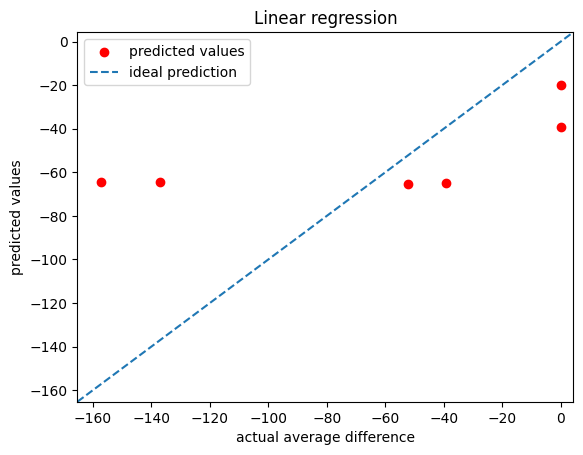

In [20]:
plot_regression_quality(y_test, y_test_predict_lin_reg, 'Linear regression')

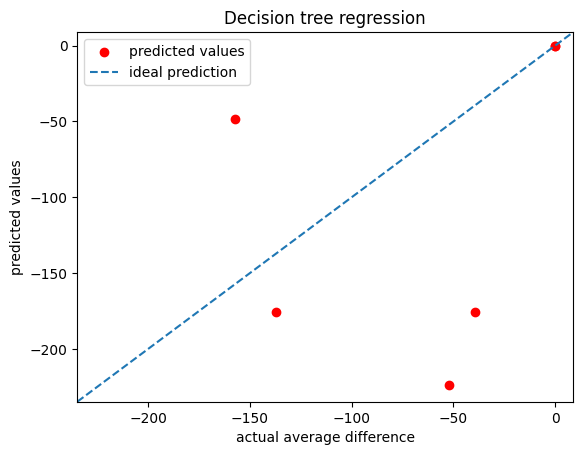

In [21]:
plot_regression_quality(y_test, y_test_predict_tree_reg, 'Decision tree regression')

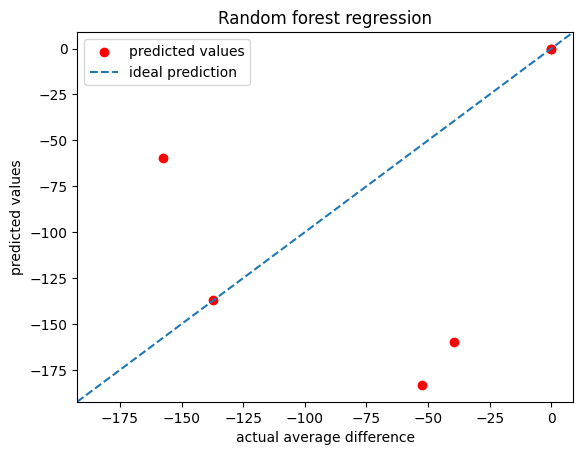

In [22]:
plot_regression_quality(y_test, y_test_predict_rf_reg, 'Random forest regression')

Points would lie on the x=y diagonal.